<a href="https://colab.research.google.com/github/zohrehasadi00/automatic_image_analysis/blob/main/notebooks/SkinLesionTriage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reproducible Pipeline

In [77]:
# import collection

import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

from scipy.sparse import find

In [78]:
#set seed for reproducibility
random_state = 42
torch.manual_seed(random_state)
np.random.seed(random_state)

In [79]:
# connect Drive for data
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [80]:
# set project_dir
project_dir = Path('.') / 'drive' / 'MyDrive' / 'AIA_SkinLesion_Projekt'

# Data Exploration

In this section you will find:


*   the classification labels (malignant and benign) are converted into numerical values
* a sanity check is conducted to ensure that no image files listed in the metadata are missing
* descriptive statistic on the distribution of the complete dataset




In [81]:
#path to image data
data_raw =[
    str(project_dir / 'data' / 'raw' / 'HAM10000_images_part_1'),
    str(project_dir / 'data' / 'raw' / 'HAM10000_images_part_2')
    ]

# load metadata
csv_path    = project_dir / 'HAM10000_metadata.csv'
df_metadata = pd.read_csv(csv_path)


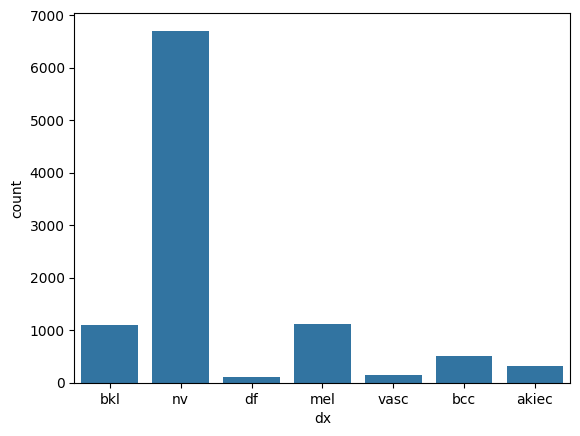

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64
After recoding: label
0    8061
1    1627
Name: count, dtype: int64
Check for removed akiec: dx
nv      6705
mel     1113
bkl     1099
bcc      514
vasc     142
df       115
Name: count, dtype: int64


In [82]:
##### explore benign and malignant classes

sns.countplot(x=df_metadata['dx'], legend=False)
plt.show()

print(df_metadata["dx"].value_counts())

###Recoded based on diagnosis description in https://www.nature.com/articles/sdata2018161
#akiec not considered as it is not clear bening neither malignant: "There is, however, agreement that these lesions may progress to invasive squamous cell carcinoma – which is usually not pigmented."
#bcc -> malignant
# mel malignant per definition
# bkl, df, nv, vasc -> benign

df_metadata = df_metadata.drop(df_metadata[df_metadata['dx'] == 'akiec'].index)
df_metadata['label'] = df_metadata['dx'].isin(['mel', 'bcc']).astype(int)

#sanity check
print(f"After recoding: {df_metadata["label"].value_counts()}")
print(f"Check for removed akiec: {df_metadata["dx"].value_counts()}")

#save converted file back to Drive
output_dir = project_dir
os.makedirs(output_dir, exist_ok=True)

df_metadata.to_csv(os.path.join(output_dir, 'HAM10000_metadata_converted.csv'), index=False)


In [83]:
##### Sanity check for missing image files #####
missing = []

for idx in range(len(df_metadata)):
    img_id = df_metadata.iloc[idx]['image_id']
    img_name = img_id + '.jpg'
    found = any(os.path.exists(os.path.join(d, img_name)) for d in data_raw)
    if not found:
        missing.append(img_name)

print(f"{len(missing)} images could not be found")
print(missing[:10])




0 images could not be found
[]


Shape of data : (9688, 8)
Nummber of dimensions : 2

Class distribution (0=benign, 1=melanoma):
label
0    8061
1    1627
Name: count, dtype: int64


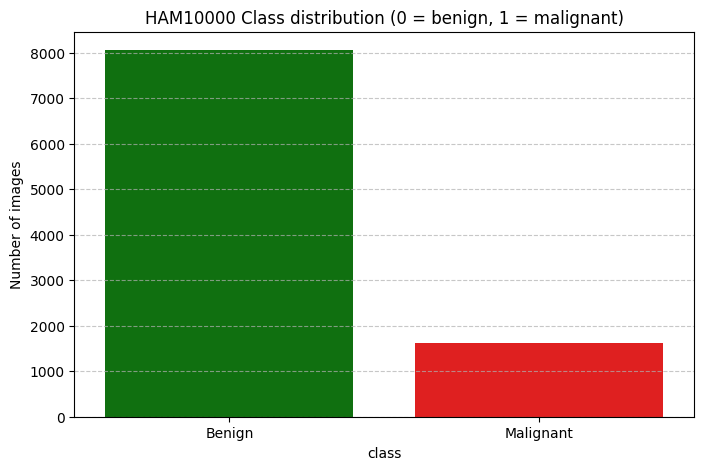


Impression of the data:


,lesion_id,image_id,dx,dx_type,age,sex,localization,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,0
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,0
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,0
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,0
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,0


In [84]:
##### plot class distribution #####
def plotClassDistribution(dataset):
  plt.figure(figsize=(8, 5))
  sns.countplot(x='label', data=dataset, hue='label', palette=['green', 'red'], legend=False)
  plt.title('HAM10000 Class distribution (0 = benign, 1 = malignant)')
  plt.xlabel('class')
  plt.ylabel('Number of images')
  plt.xticks([0, 1], ['Benign', 'Malignant'])
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.show()


print(f"Shape of data : {df_metadata.shape}")
print(f"Nummber of dimensions : {df_metadata.ndim}")
print(f"\nClass distribution (0=benign, 1=melanoma):\n{df_metadata['label'].value_counts()}")
plotClassDistribution(df_metadata)

print(f"\nImpression of the data:")
df_metadata.head()


# Split training, test and validation set

In this section the data is split to train, validation and test set. All splits are saved in distinct csv-files on Drive, so that we can use for both pipelines the same splits.

**Train set**: Is used for training

**Validation set** (12.5% of the train set): Is used for hyperparameter training

**Test set** (20% of the original dataset): Is used for evaluating the model's performance


     lesion_id  label
0  HAM_0000000      0
1  HAM_0000001      0
2  HAM_0000002      1
3  HAM_0000003      0
4  HAM_0000004      0


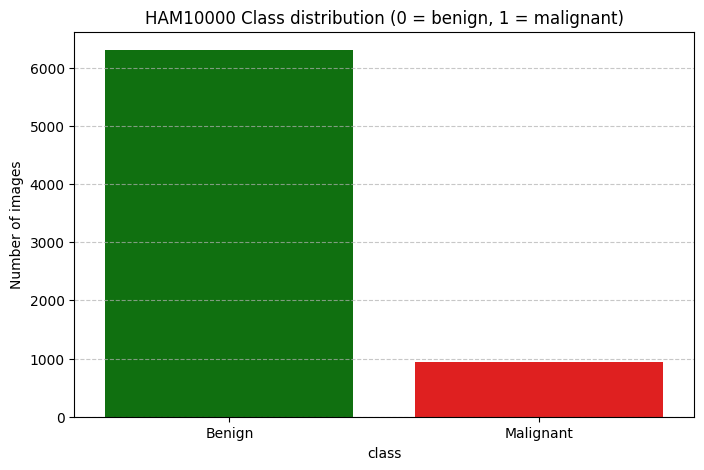


Class distribution (0=benign, 1=melanoma):
label
0    6301
1     941
Name: count, dtype: int64


In [85]:
## avoid data leakage by split data based on lesion_id

# new data frame that only contains different lesions
df_lesion = df_metadata.groupby('lesion_id')['label'].first().reset_index()
print(df_lesion.head())
plotClassDistribution(df_lesion)
print(f"\nClass distribution (0=benign, 1=melanoma):\n{df_lesion['label'].value_counts()}")


In [86]:
train_val_lesions_df, test_lesions_df = train_test_split(df_lesion, test_size=0.20, stratify=df_lesion['label'], random_state=random_state) # set seed

# create validation set for hyperparameter fine tuning
train_lesions_df, val_lesions_df = train_test_split(train_val_lesions_df, test_size=0.125, stratify=train_val_lesions_df['label'], random_state=random_state)

print(f"training set: {len(train_lesions_df)}")
print(f"validation set: {len(val_lesions_df)}")
print(f"test set: {len(test_lesions_df)}")



training set: 5068
validation set: 725
test set: 1449


In [87]:
train_df = df_metadata[df_metadata['lesion_id'].isin(train_lesions_df['lesion_id'])]
val_df   = df_metadata[df_metadata['lesion_id'].isin(val_lesions_df['lesion_id'])]
test_df  = df_metadata[df_metadata['lesion_id'].isin(test_lesions_df['lesion_id'])]

print(f"Train-Bilder: {len(train_df)}")
print(f"Val-Bilder:   {len(val_df)}")
print(f"Test-Bilder:  {len(test_df)}")

#sanity check for data leakage
train_ids = set(train_df['image_id'])
val_ids   = set(val_df['image_id'])
test_ids  = set(test_df['image_id'])
assert len(train_ids & val_ids) == 0
assert len(train_ids & test_ids) == 0
assert len(val_ids & test_ids) == 0
print("No data leakage between splits ")


##save split sets to Drive
output_dir = '/content/drive/MyDrive/AIA_SkinLesion_Projekt/splits'
os.makedirs(output_dir, exist_ok=True)

train_df.to_csv(os.path.join(output_dir, 'train.csv'), index=False)
val_df.to_csv(os.path.join(output_dir, 'val.csv'), index=False)
test_df.to_csv(os.path.join(output_dir, 'test.csv'), index=False)

Train-Bilder: 6792
Val-Bilder:   979
Test-Bilder:  1917
No data leakage between splits 


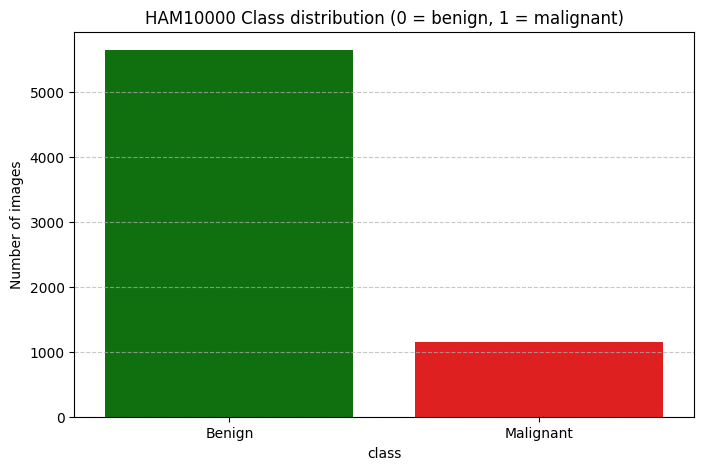

                age   sex localization
count   6744.000000  6792         6792
unique          NaN     3           15
top             NaN  male         back
freq            NaN  3622         1543
mean      51.379745   NaN          NaN
std       16.900738   NaN          NaN
min        0.000000   NaN          NaN
25%       40.000000   NaN          NaN
50%       50.000000   NaN          NaN
75%       65.000000   NaN          NaN
max       85.000000   NaN          NaN


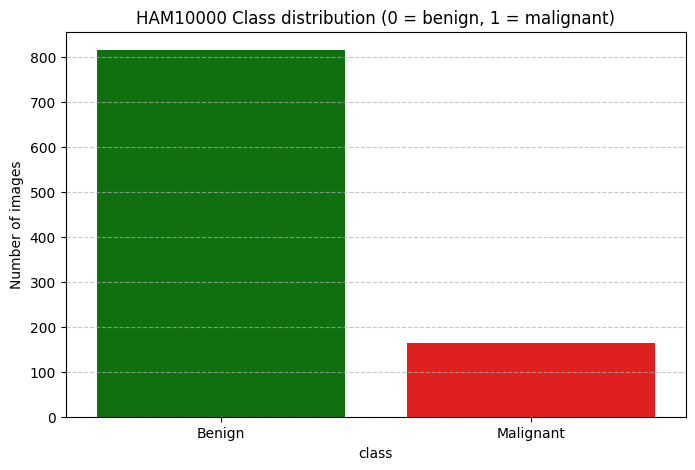

               age   sex localization
count   978.000000   979          979
unique         NaN     3           14
top            NaN  male         back
freq           NaN   572          219
mean     52.070552   NaN          NaN
std      17.271157   NaN          NaN
min       0.000000   NaN          NaN
25%      40.000000   NaN          NaN
50%      50.000000   NaN          NaN
75%      65.000000   NaN          NaN
max      85.000000   NaN          NaN


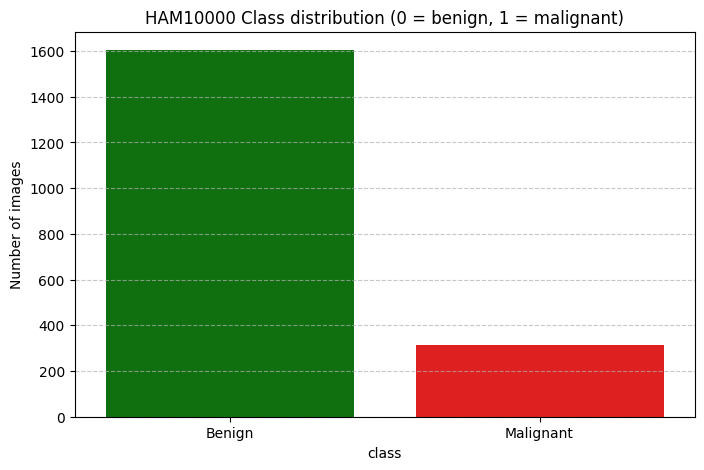

                age   sex localization
count   1909.000000  1917         1917
unique          NaN     3           15
top             NaN  male         back
freq            NaN   991          401
mean      50.955998   NaN          NaN
std       16.714245   NaN          NaN
min        0.000000   NaN          NaN
25%       40.000000   NaN          NaN
50%       50.000000   NaN          NaN
75%       65.000000   NaN          NaN
max       85.000000   NaN          NaN


In [88]:
#explore splits
dataset = [train_df, val_df, test_df]


for df_split in dataset:
  plotClassDistribution(df_split)
  print(df_split[["age", "sex", "localization"]].describe(include="all"))

# Handling unbalanced data in train set

In [89]:
train_df.head()


,lesion_id,image_id,dx,dx_type,age,sex,localization,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,0
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,0
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,0
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,0
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,0


In [90]:
### balance mel and bening in trainset

benign_df = train_df[train_df['label'] == 0]
mel_df   = train_df[train_df['label'] == 1]


benign_downsampled = benign_df.sample(n=len(mel_df), random_state=42)
train_balanced_df  = pd.concat([benign_downsampled, mel_df])
print(train_balanced_df['label'].value_counts())


print('Check ratio between different lesions in both sets')
df_be_difflesion = benign_downsampled.groupby('lesion_id')['label'].first().reset_index()
print(f'benign: {len(df_be_difflesion)}')

df_mel_difflesion = mel_df.groupby('lesion_id')['label'].first().reset_index()
print(f'malignant: {len(df_mel_difflesion)}')


train_balanced_df.head()

label
0    1150
1    1150
Name: count, dtype: int64
Check ratio between different lesions in both sets
benign: 1082
malignant: 659


,lesion_id,image_id,dx,dx_type,age,sex,localization,label
9203,HAM_0005173,ISIC_0025400,nv,histo,85.0,male,back,0
5640,HAM_0002077,ISIC_0031936,nv,follow_up,40.0,female,lower extremity,0
5355,HAM_0003545,ISIC_0029718,nv,follow_up,80.0,male,trunk,0
3141,HAM_0000724,ISIC_0026038,nv,follow_up,65.0,female,back,0
144,HAM_0006654,ISIC_0033691,bkl,histo,75.0,male,back,0


In [91]:
output_dir = '/content/drive/MyDrive/AIA_SkinLesion_Projekt/splits'
os.makedirs(output_dir, exist_ok=True)

train_balanced_df.to_csv(os.path.join(output_dir, 'train_balanced.csv'), index=False)